Saving flipkart_customer_data_2000.csv to flipkart_customer_data_2000 (1).csv
Dataset Loaded: (2000, 2)
Columns: Index(['instruction', 'intent'], dtype='object')


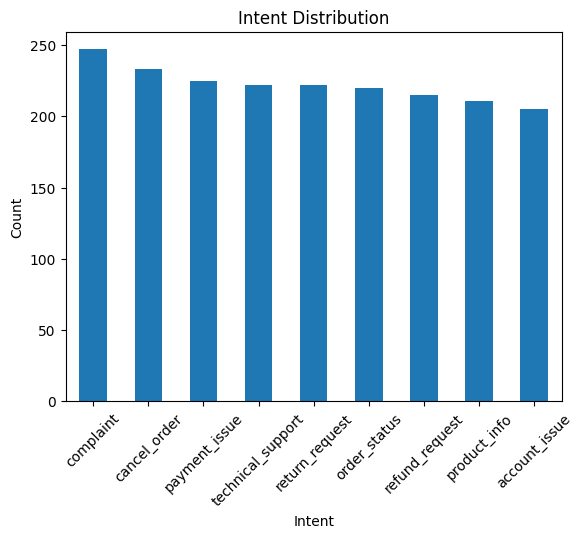

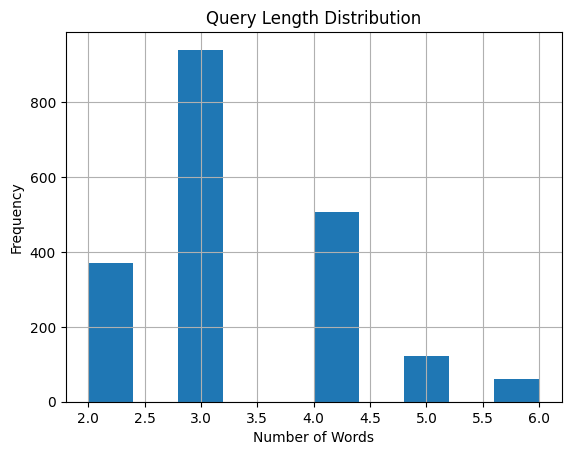


Accuracy: 1.0

Classification Report:

                   precision    recall  f1-score   support

    account_issue       1.00      1.00      1.00        45
     cancel_order       1.00      1.00      1.00        48
        complaint       1.00      1.00      1.00        55
     order_status       1.00      1.00      1.00        31
    payment_issue       1.00      1.00      1.00        49
     product_info       1.00      1.00      1.00        45
   refund_request       1.00      1.00      1.00        47
   return_request       1.00      1.00      1.00        41
technical_support       1.00      1.00      1.00        39

         accuracy                           1.00       400
        macro avg       1.00      1.00      1.00       400
     weighted avg       1.00      1.00      1.00       400



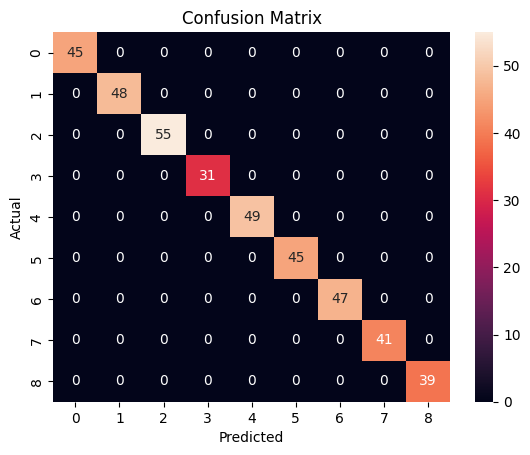

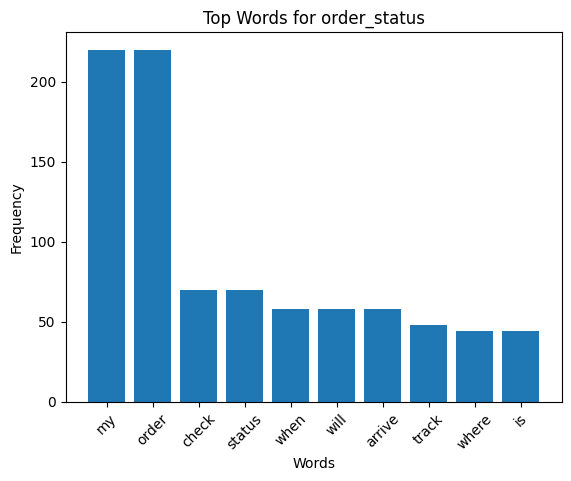

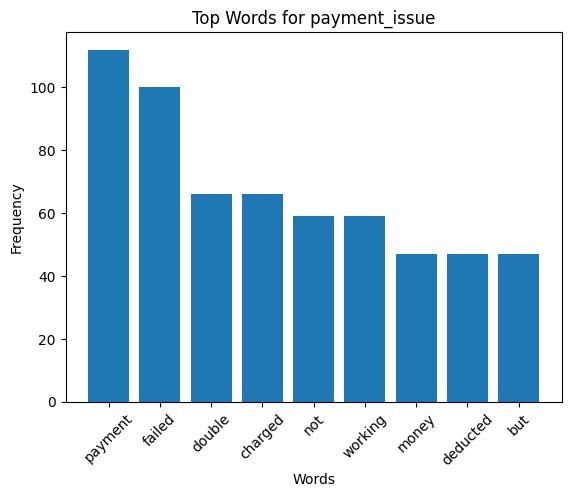

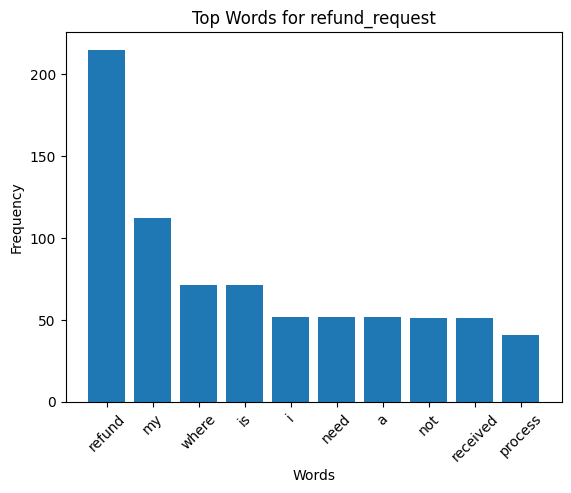

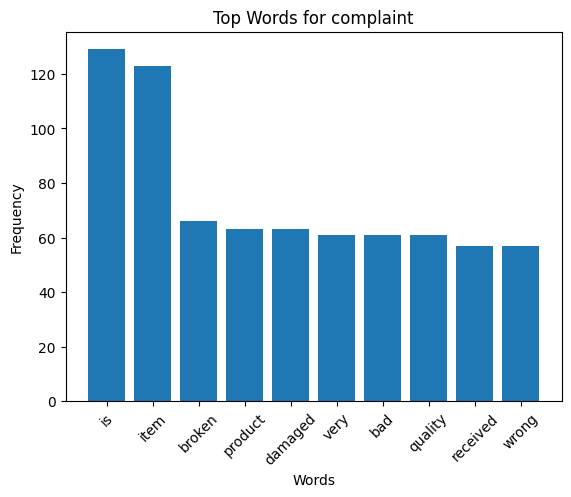

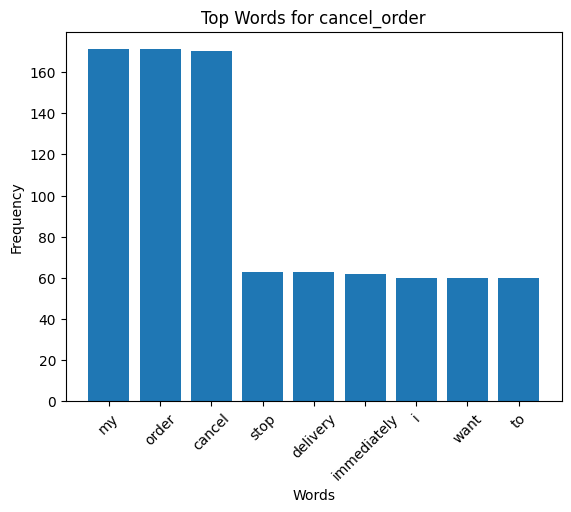

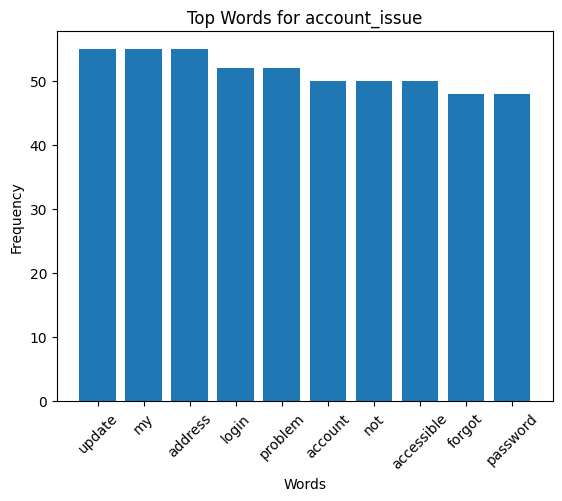

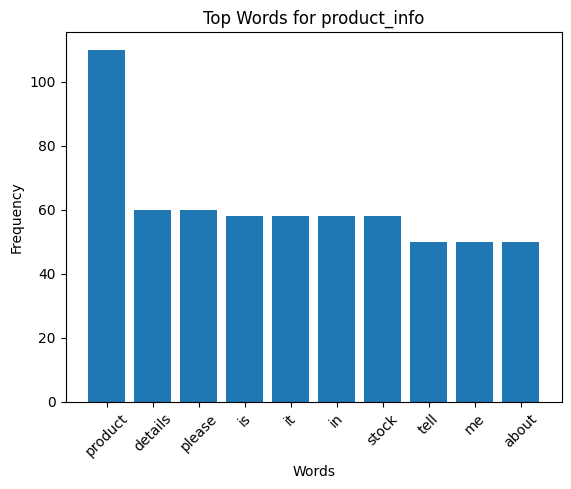

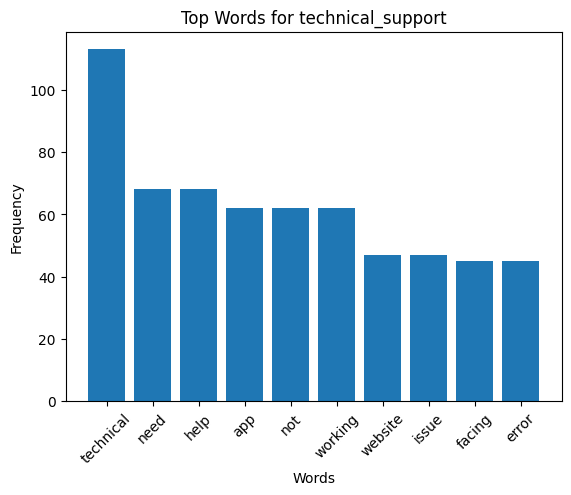

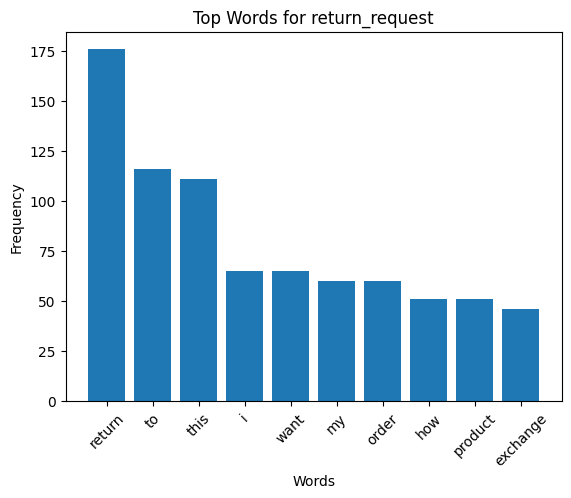

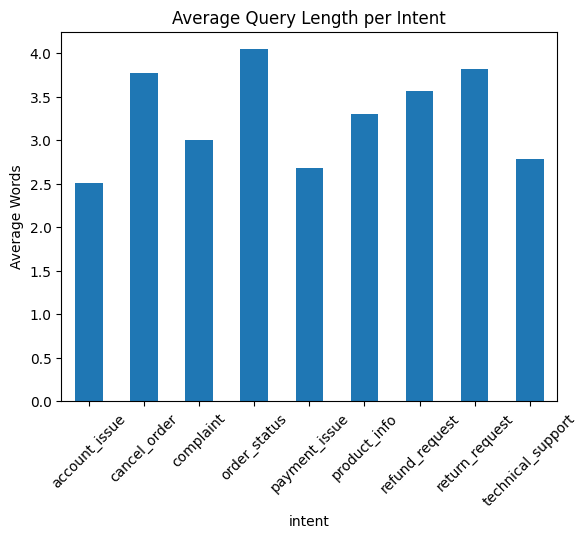

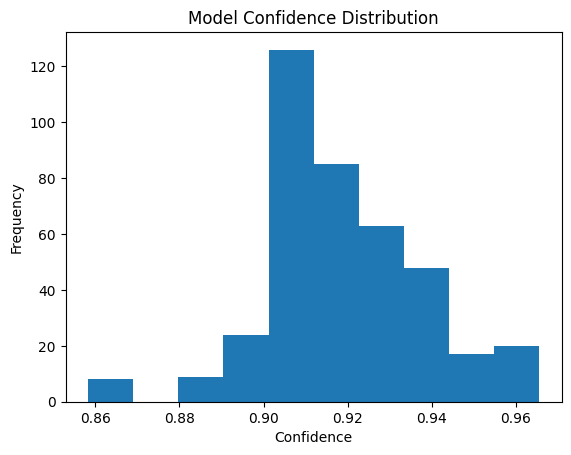

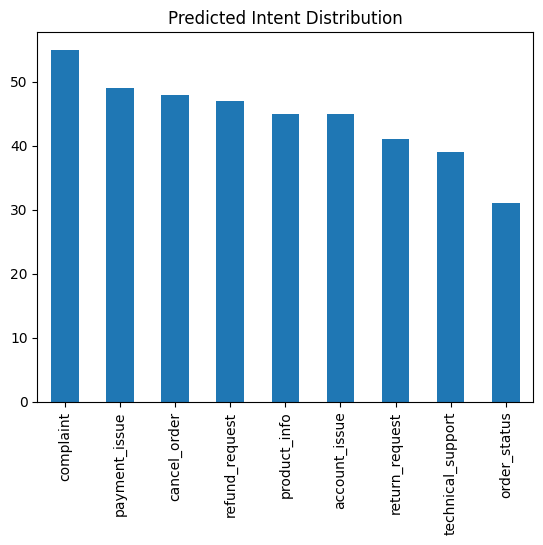


✅ No misclassifications (Model performing very well!)

Sample Predictions:

                Query   Predicted Intent
0       I want refund     refund_request
1     Cancel my order       cancel_order
2      Payment failed      payment_issue
3   Where is my order       order_status
4  App is not working  technical_support


In [2]:
# =========================================
# 1. INSTALL LIBRARIES
# =========================================
!pip install pandas numpy scikit-learn matplotlib seaborn

# =========================================
# 2. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================================
# 3. UPLOAD DATASET
# =========================================
from google.colab import files
uploaded = files.upload()

# =========================================
# 4. LOAD DATASET
# =========================================
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset Loaded:", df.shape)
print("Columns:", df.columns)

# =========================================
# 5. PREPARE DATA
# =========================================
df = df[['instruction', 'intent']]
df.rename(columns={'instruction': 'query'}, inplace=True)

# =========================================
# 6. CLEAN TEXT
# =========================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['clean_query'] = df['query'].apply(clean_text)

# =========================================
# 7. VISUAL 1: INTENT DISTRIBUTION
# =========================================
plt.figure()
df['intent'].value_counts().plot(kind='bar')
plt.title("Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# =========================================
# 8. QUERY LENGTH DISTRIBUTION
# =========================================
df['query_length'] = df['clean_query'].apply(lambda x: len(x.split()))

plt.figure()
df['query_length'].hist()
plt.title("Query Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# =========================================
# 9. TRAIN TEST SPLIT
# =========================================
X = df['clean_query']
y = df['intent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# 10. TF-IDF
# =========================================
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# =========================================
# 11. MODEL TRAINING
# =========================================
model = LogisticRegression(max_iter=200)
model.fit(X_train_vec, y_train)

# =========================================
# 12. MODEL EVALUATION
# =========================================
y_pred = model.predict(X_test_vec)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================================
# 13. VISUAL 2: CONFUSION MATRIX
# =========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================
# 14. VISUAL 3: TOP WORDS PER INTENT (BAR CHART)
# =========================================
for intent in df['intent'].unique():
    text = " ".join(df[df['intent'] == intent]['clean_query'])
    words = text.split()
    common_words = Counter(words).most_common(10)

    words_list = [w[0] for w in common_words]
    counts = [w[1] for w in common_words]

    plt.figure()
    plt.bar(words_list, counts)
    plt.title(f"Top Words for {intent}")
    plt.xticks(rotation=45)
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.show()

# =========================================
# 15. VISUAL 4: INTENT-WISE AVG QUERY LENGTH
# =========================================
avg_len = df.groupby('intent')['query_length'].mean()

plt.figure()
avg_len.plot(kind='bar')
plt.title("Average Query Length per Intent")
plt.ylabel("Average Words")
plt.xticks(rotation=45)
plt.show()

# =========================================
# 16. VISUAL 5: MODEL CONFIDENCE
# =========================================
probs = model.predict_proba(X_test_vec)
confidence = probs.max(axis=1)

plt.figure()
plt.hist(confidence)
plt.title("Model Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

# =========================================
# 17. VISUAL 6: PREDICTED INTENT DISTRIBUTION
# =========================================
plt.figure()
pd.Series(y_pred).value_counts().plot(kind='bar')
plt.title("Predicted Intent Distribution")
plt.show()

# =========================================
# 18. VISUAL 7: MISCLASSIFIED EXAMPLES
# =========================================
misclassified = pd.DataFrame({
    'Query': X_test,
    'Actual': y_test,
    'Predicted': y_pred
})

misclassified = misclassified[misclassified['Actual'] != misclassified['Predicted']]

if misclassified.empty:
    print("\n✅ No misclassifications (Model performing very well!)")
else:
    print("\nMisclassified Examples:\n")
    print(misclassified.head(10))

# =========================================
# 19. SAMPLE PREDICTIONS (TABLE)
# =========================================
sample_queries = [
    "I want refund",
    "Cancel my order",
    "Payment failed",
    "Where is my order",
    "App is not working"
]

cleaned = [clean_text(q) for q in sample_queries]
vec = vectorizer.transform(cleaned)

predictions = model.predict(vec)

results = pd.DataFrame({
    "Query": sample_queries,
    "Predicted Intent": predictions
})

print("\nSample Predictions:\n")
print(results)